In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohiteng/amazon-sales-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
Path to dataset files: /kaggle/input/amazon-sales-dataset


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [13]:
df = pd.read_csv('/content/drive/MyDrive/HR-Employee-Attrition.csv')

In [ ]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

There are no missing values in the dataset

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicate rows.

Distribution of Target Variable

<Axes: xlabel='Attrition'>

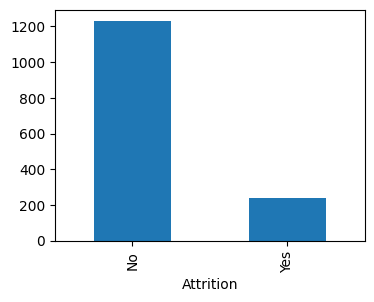

In [ ]:
GroupedData=df.groupby('Attrition').size()
GroupedData.plot(kind='bar', figsize=(4,3))

The target variable is imbalanced

In [ ]:
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


In [14]:
categorical_features = ['BusinessTravel', 'Department','EducationField', 'JobRole', 'MaritalStatus']#,'Gender', 'OverTime']

binary_features = ['Gender', 'OverTime']

numeric_features = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

ordinal_features = ['Education' ,'EnvironmentSatisfaction', 'JobInvolvement','JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

cat_features = categorical_features + binary_features


Distribution of Categorical Predictors

In [15]:
def PlotBarCharts(inpData, colsToPlot):
    %matplotlib inline

    # Generating multiple subplots
    fig, subPlot=plt.subplots(nrows=1, ncols=len(colsToPlot), figsize=(20,5))
    fig.suptitle('Bar charts of: '+ str(colsToPlot))

    for colName, plotNumber in zip(colsToPlot, range(len(colsToPlot))):
        inpData.groupby(colName).size().plot(kind='bar',ax=subPlot[plotNumber])

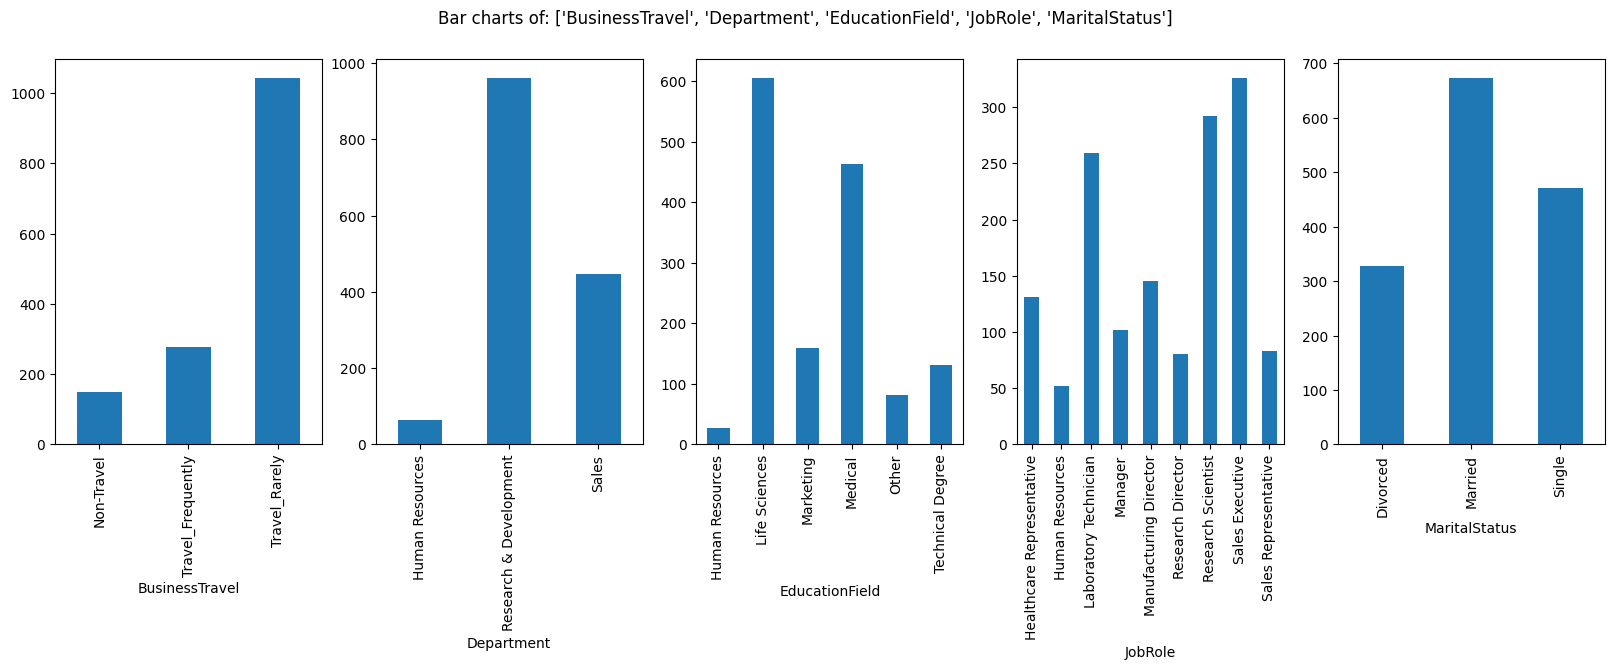

In [16]:
PlotBarCharts(inpData=df, colsToPlot=categorical_features)

Distribution of Continuous Predictors using Histograms

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'DailyRate'}>,
        <Axes: title={'center': 'DistanceFromHome'}>,
        <Axes: title={'center': 'HourlyRate'}>],
       [<Axes: title={'center': 'MonthlyIncome'}>,
        <Axes: title={'center': 'MonthlyRate'}>,
        <Axes: title={'center': 'NumCompaniesWorked'}>,
        <Axes: title={'center': 'PercentSalaryHike'}>],
       [<Axes: title={'center': 'TotalWorkingYears'}>,
        <Axes: title={'center': 'TrainingTimesLastYear'}>,
        <Axes: title={'center': 'YearsAtCompany'}>,
        <Axes: title={'center': 'YearsInCurrentRole'}>],
       [<Axes: title={'center': 'YearsSinceLastPromotion'}>,
        <Axes: title={'center': 'YearsWithCurrManager'}>, <Axes: >,
        <Axes: >]], dtype=object)

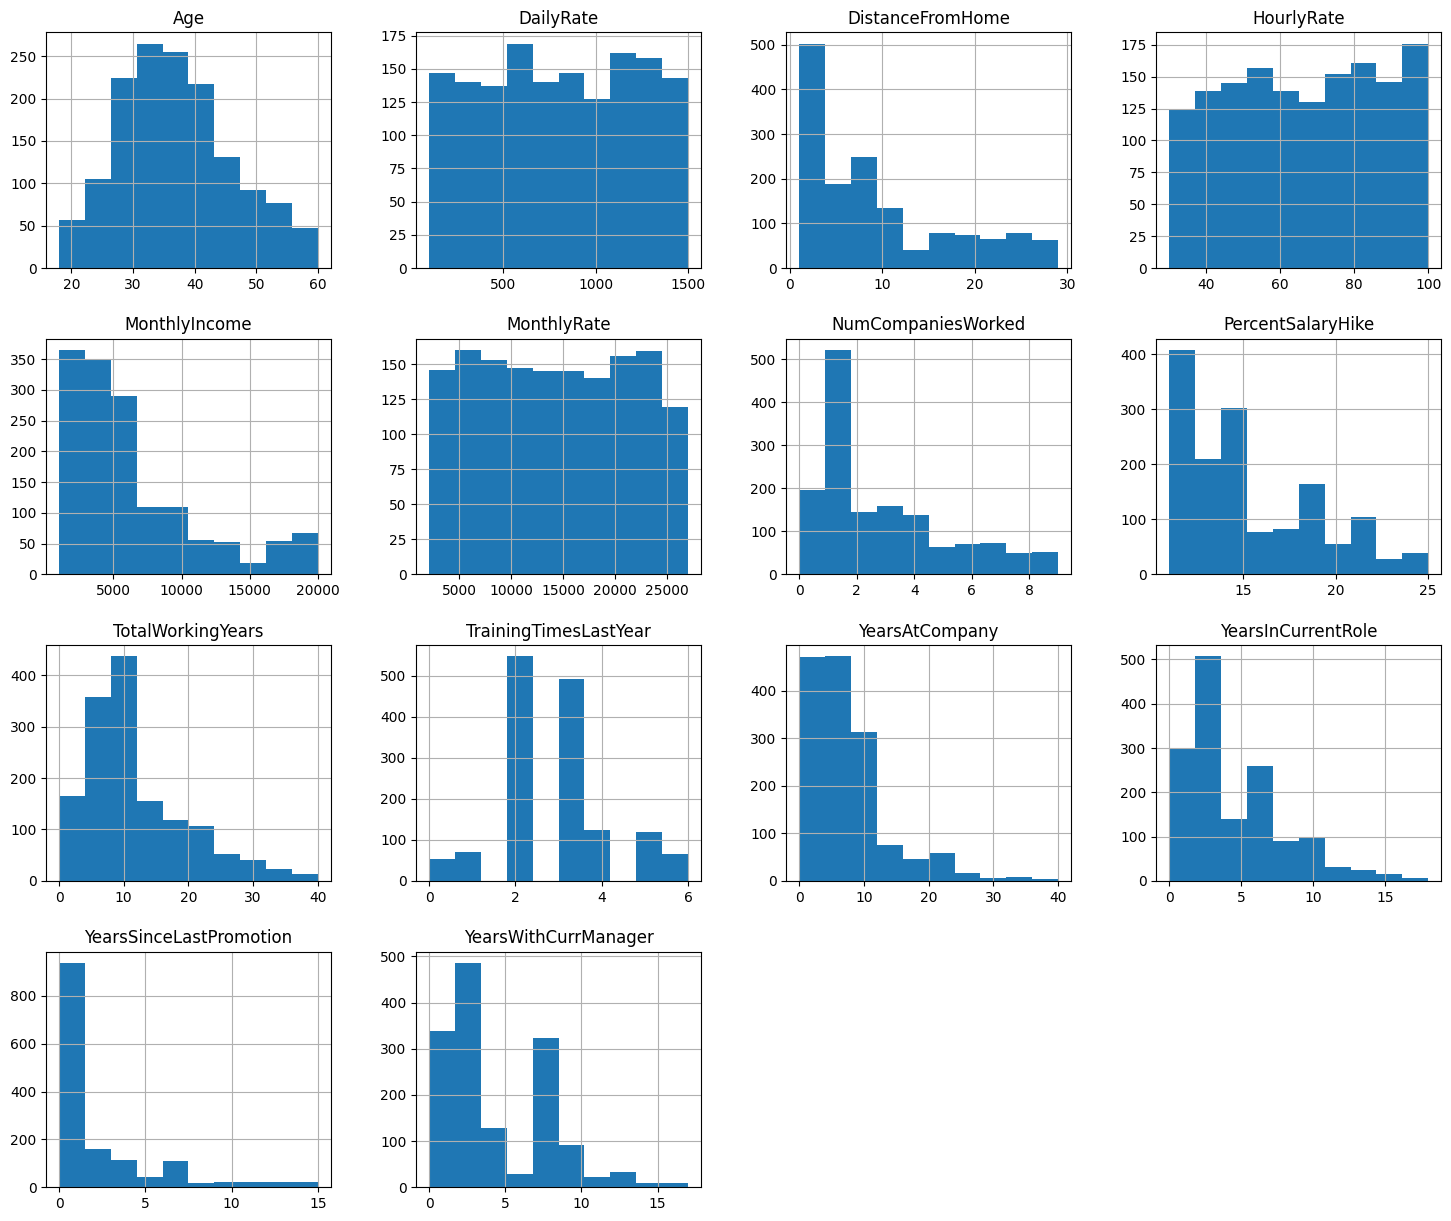

In [ ]:
df.hist(numeric_features, figsize=(18,15))

Relaionship: Continuous Predictor vs. Categorical Target by Plotting Box Plots

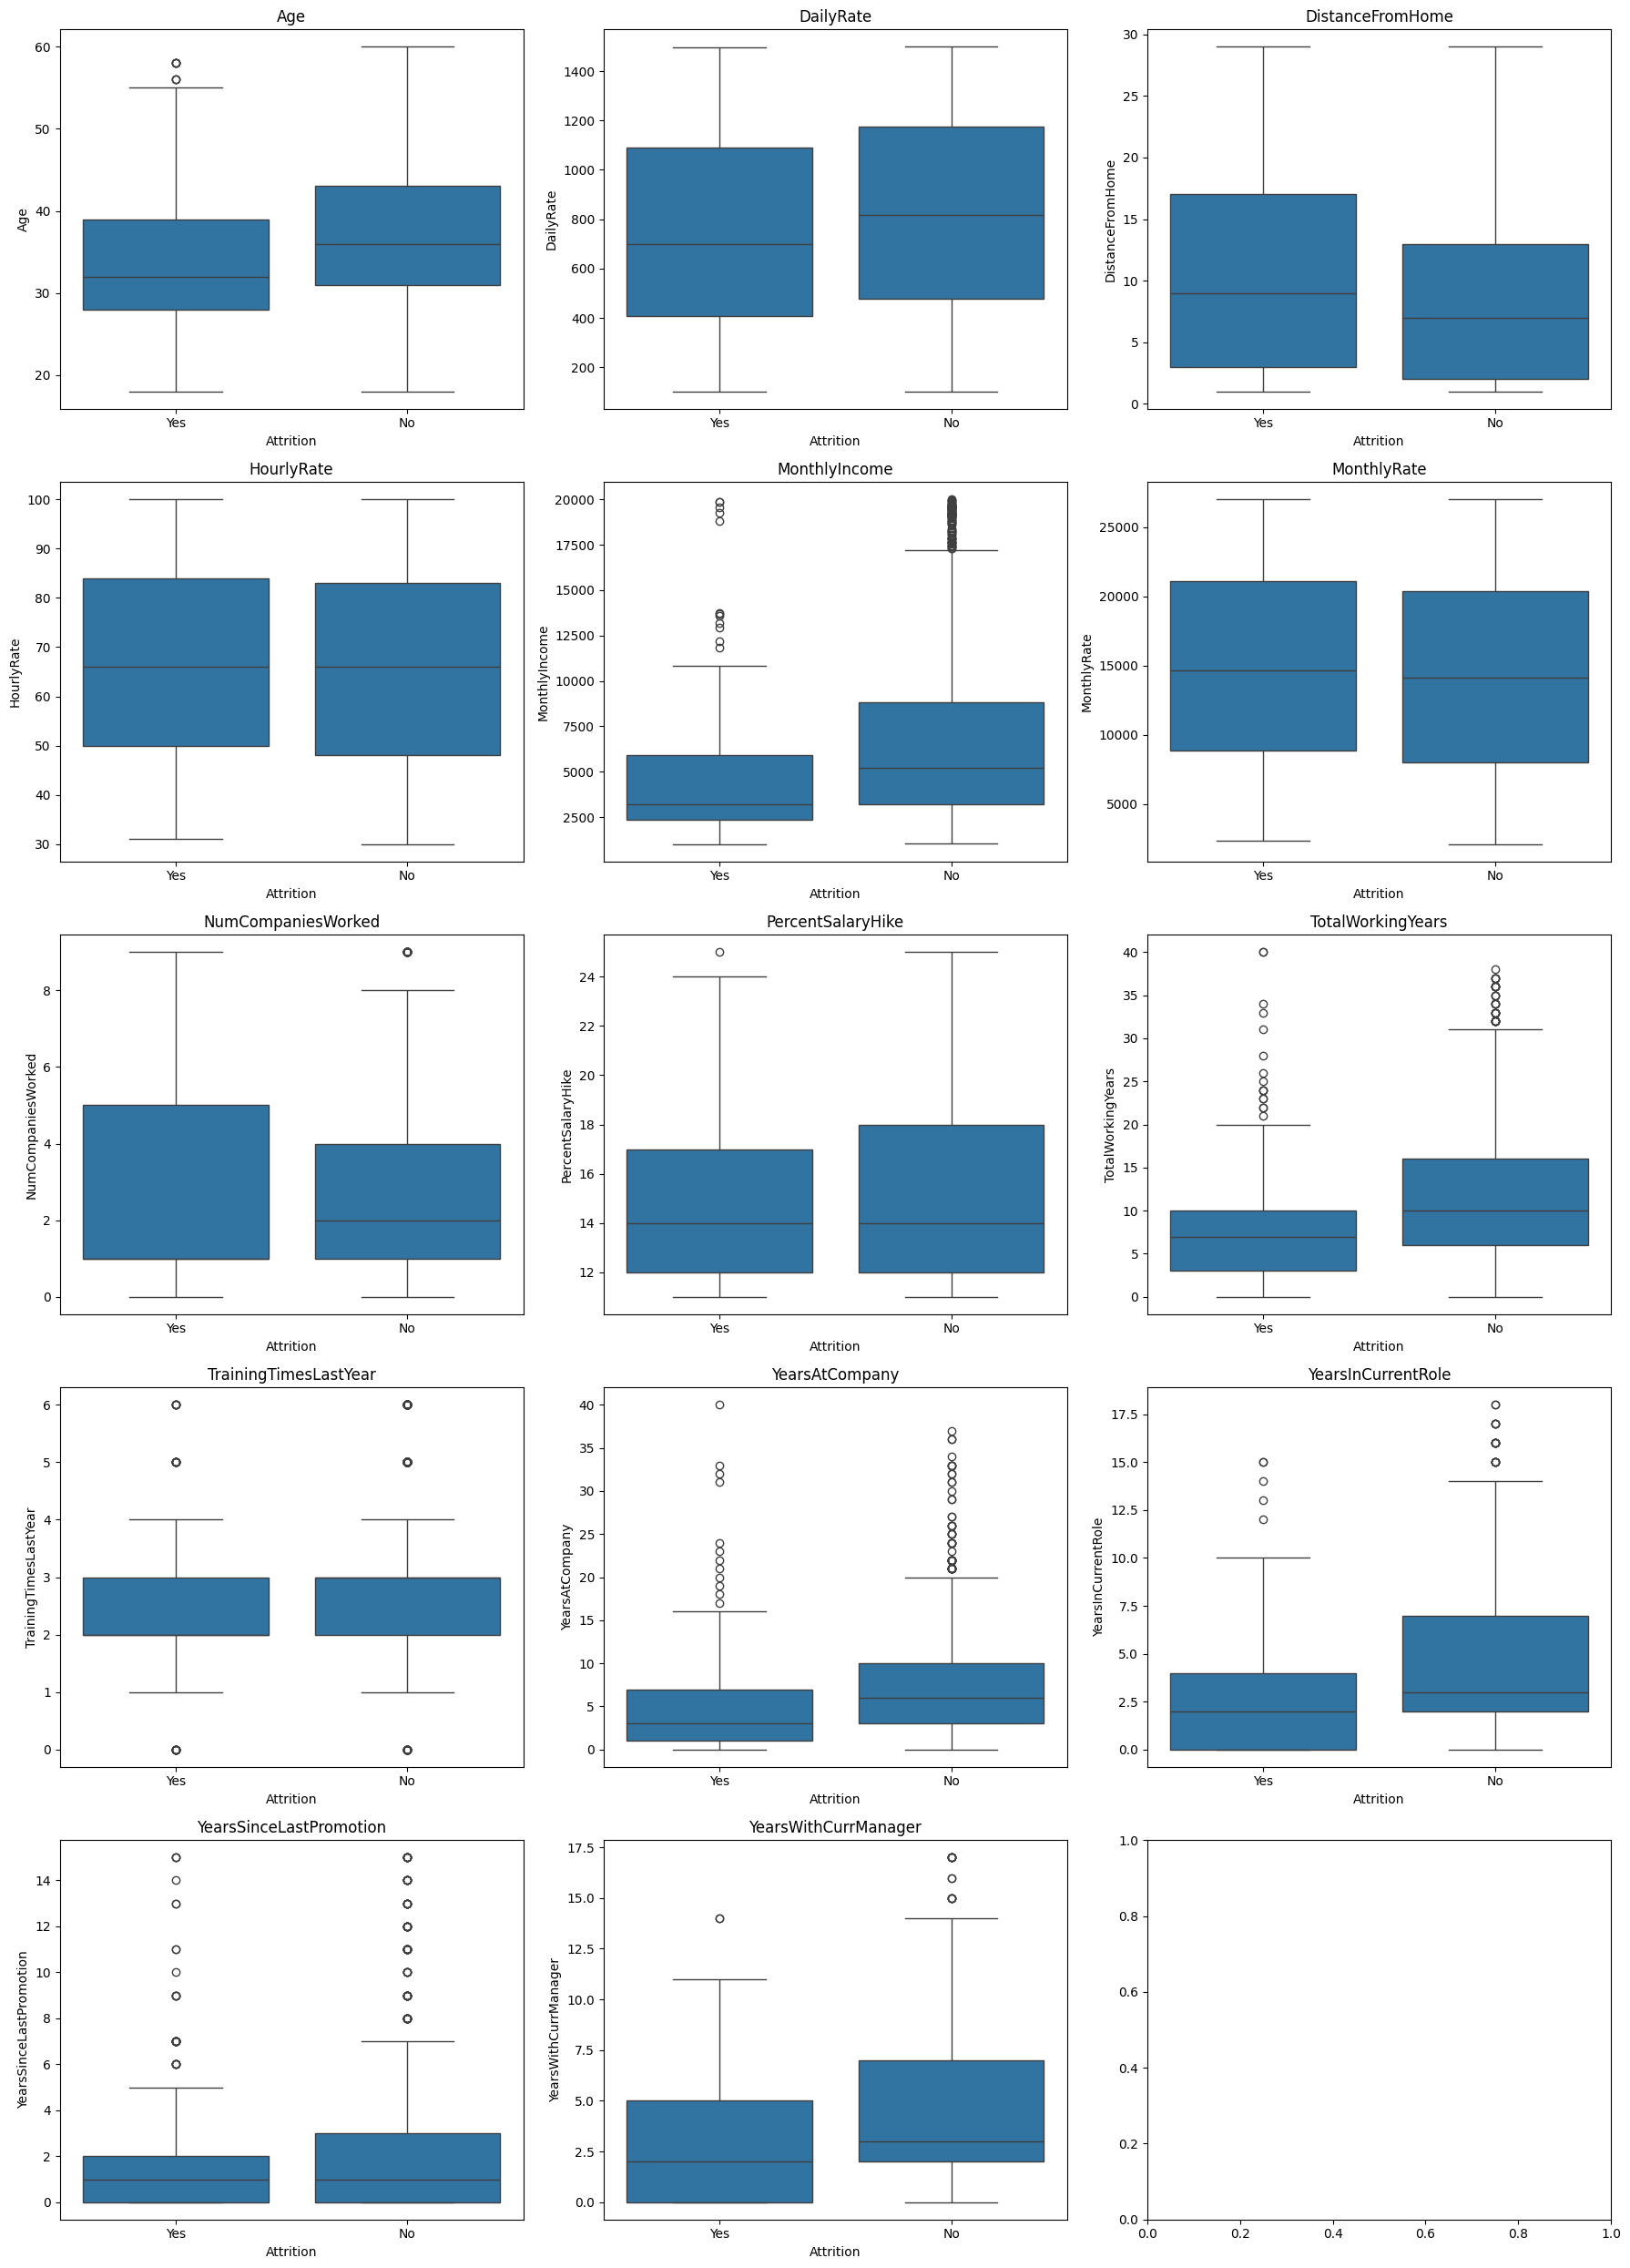

In [17]:
n = len(numeric_features)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(
        data=df,
        x='Attrition',
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()



In [18]:
SelectedPredictors=[]


def FunctionAnova(inpData, TargetVariable, ContinuousPredictorList):
    from scipy.stats import f_oneway

    # Creating an empty list of final selected predictors

    print('##### ANOVA Results ##### \n')
    for predictor in ContinuousPredictorList:
        CategoryGroupLists=inpData.groupby(TargetVariable)[predictor].apply(list)
        AnovaResults = f_oneway(*CategoryGroupLists)

        # If the ANOVA P-Value is <0.05, that means we reject H0
        if (AnovaResults[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', AnovaResults[1])
            SelectedPredictors.append(predictor)
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', AnovaResults[1])

    return(SelectedPredictors)

In [19]:
FunctionAnova(inpData=df, TargetVariable='Attrition', ContinuousPredictorList=numeric_features)

##### ANOVA Results ##### 

Age is correlated with Attrition | P-Value: 8.356308021102401e-10
DailyRate is correlated with Attrition | P-Value: 0.02985816066026101
DistanceFromHome is correlated with Attrition | P-Value: 0.002793060080213499
HourlyRate is NOT correlated with Attrition | P-Value: 0.7931347689944519
MonthlyIncome is correlated with Attrition | P-Value: 7.147363985353002e-10
MonthlyRate is NOT correlated with Attrition | P-Value: 0.5611235982243229
NumCompaniesWorked is NOT correlated with Attrition | P-Value: 0.09552526205649159
PercentSalaryHike is NOT correlated with Attrition | P-Value: 0.6056128238894396
TotalWorkingYears is correlated with Attrition | P-Value: 4.061878111266676e-11
TrainingTimesLastYear is correlated with Attrition | P-Value: 0.02257849973719727
YearsAtCompany is correlated with Attrition | P-Value: 2.3188716103859732e-07
YearsInCurrentRole is correlated with Attrition | P-Value: 6.003185843640478e-10
YearsSinceLastPromotion is NOT correlated with A

['Age',
 'DailyRate',
 'DistanceFromHome',
 'MonthlyIncome',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsWithCurrManager']

In [20]:
df = df.drop(columns=['HourlyRate','MonthlyRate','NumCompaniesWorked','PercentSalaryHike','YearsSinceLastPromotion'], errors='ignore')
numeric_features = [f for f in numeric_features if f in SelectedPredictors]

Relationship: Categorical Predictors vs. Categorical Target

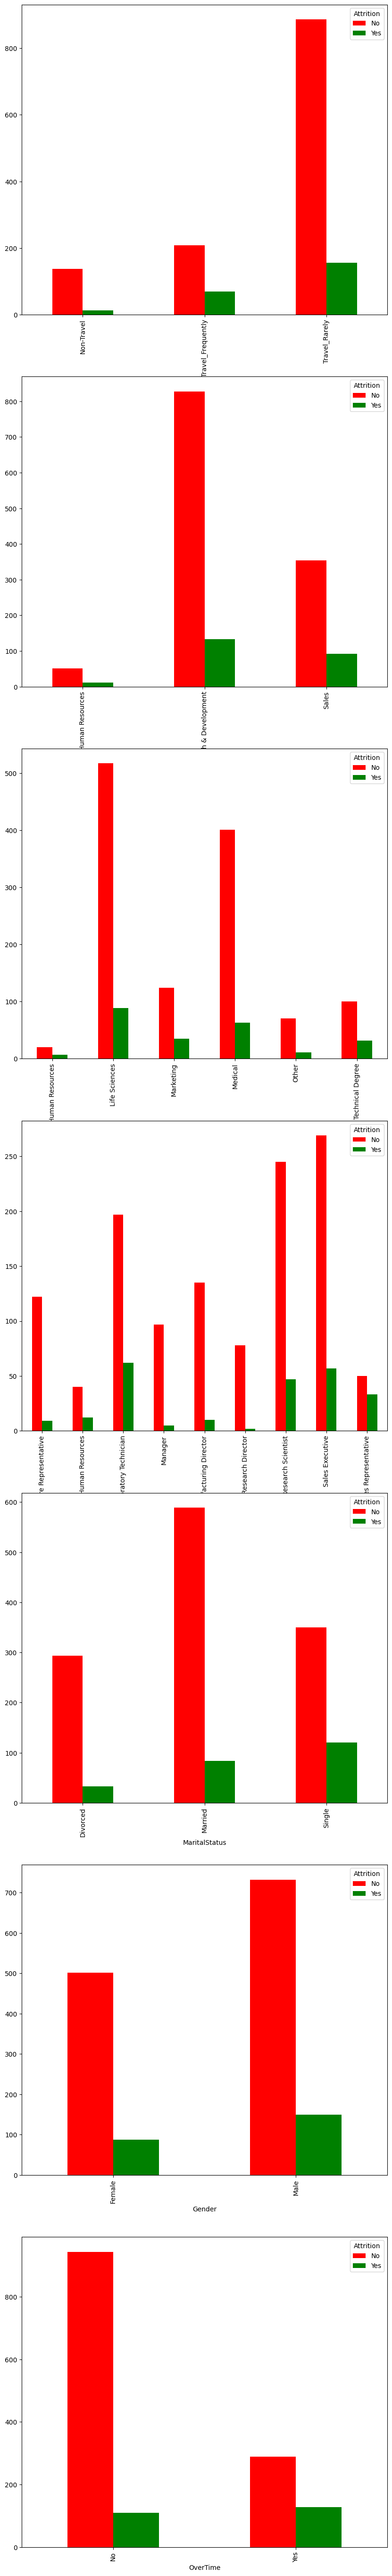

In [21]:
fig, PlotCanvas=plt.subplots(nrows=len(cat_features), ncols=1, figsize=(10,70))

for CategoricalCol , i in zip(cat_features, range(len(cat_features))):
    CrossTabResult=pd.crosstab(index=df[CategoricalCol], columns=df['Attrition'])
    CrossTabResult.plot.bar(color=['red','green'], ax=PlotCanvas[i])



In [22]:
SelectedPredictors=[]

def FunctionChisq(inpData, TargetVariable, CategoricalVariablesList):
    from scipy.stats import chi2_contingency



    for predictor in CategoricalVariablesList:
        CrossTabResult=pd.crosstab(index=inpData[TargetVariable], columns=inpData[predictor])
        ChiSqResult = chi2_contingency(CrossTabResult)

        # If the ChiSq P-Value is <0.05, that means we reject H0
        if (ChiSqResult[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', ChiSqResult[1])
            SelectedPredictors.append(predictor)
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', ChiSqResult[1])

    return(SelectedPredictors)

In [23]:
FunctionChisq(inpData=df,
              TargetVariable='Attrition',
              CategoricalVariablesList=cat_features)

BusinessTravel is correlated with Attrition | P-Value: 5.608614476449931e-06
Department is correlated with Attrition | P-Value: 0.004525606574479633
EducationField is correlated with Attrition | P-Value: 0.006773980139025222
JobRole is correlated with Attrition | P-Value: 2.752481638050657e-15
MaritalStatus is correlated with Attrition | P-Value: 9.45551106034083e-11
Gender is NOT correlated with Attrition | P-Value: 0.29057244902890855
OverTime is correlated with Attrition | P-Value: 8.15842372153832e-21


['BusinessTravel',
 'Department',
 'EducationField',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [24]:
df = df.drop(columns=['Gender'], errors='ignore')
categorical_features = [f for f in categorical_features if f in SelectedPredictors]
cat_features = [f for f in cat_features if f in SelectedPredictors]

In [25]:
correlation = df[numeric_features].corr()
correlation

,Age,DailyRate,DistanceFromHome,MonthlyIncome,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.497855,0.680381,-0.019621,0.311309,0.212901,0.202089
DailyRate,0.010661,1.000000,-0.004985,0.007707,0.014515,0.002453,-0.034055,0.009932,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,-0.017014,0.004628,-0.036942,0.009508,0.018845,0.014406
MonthlyIncome,0.497855,0.007707,-0.017014,1.000000,0.772893,-0.021736,0.514285,0.363818,0.344079
TotalWorkingYears,0.680381,0.014515,0.004628,0.772893,1.000000,-0.035662,0.628133,0.460365,0.459188
TrainingTimesLastYear,-0.019621,0.002453,-0.036942,-0.021736,-0.035662,1.000000,0.003569,-0.005738,-0.004096
YearsAtCompany,0.311309,-0.034055,0.009508,0.514285,0.628133,0.003569,1.000000,0.758754,0.769212
YearsInCurrentRole,0.212901,0.009932,0.018845,0.363818,0.460365,-0.005738,0.758754,1.000000,0.714365
YearsWithCurrManager,0.202089,-0.026363,0.014406,0.344079,0.459188,-0.004096,0.769212,0.714365,1.000000


Visualizing how much continuous features are related to each other using correlation heatmap.

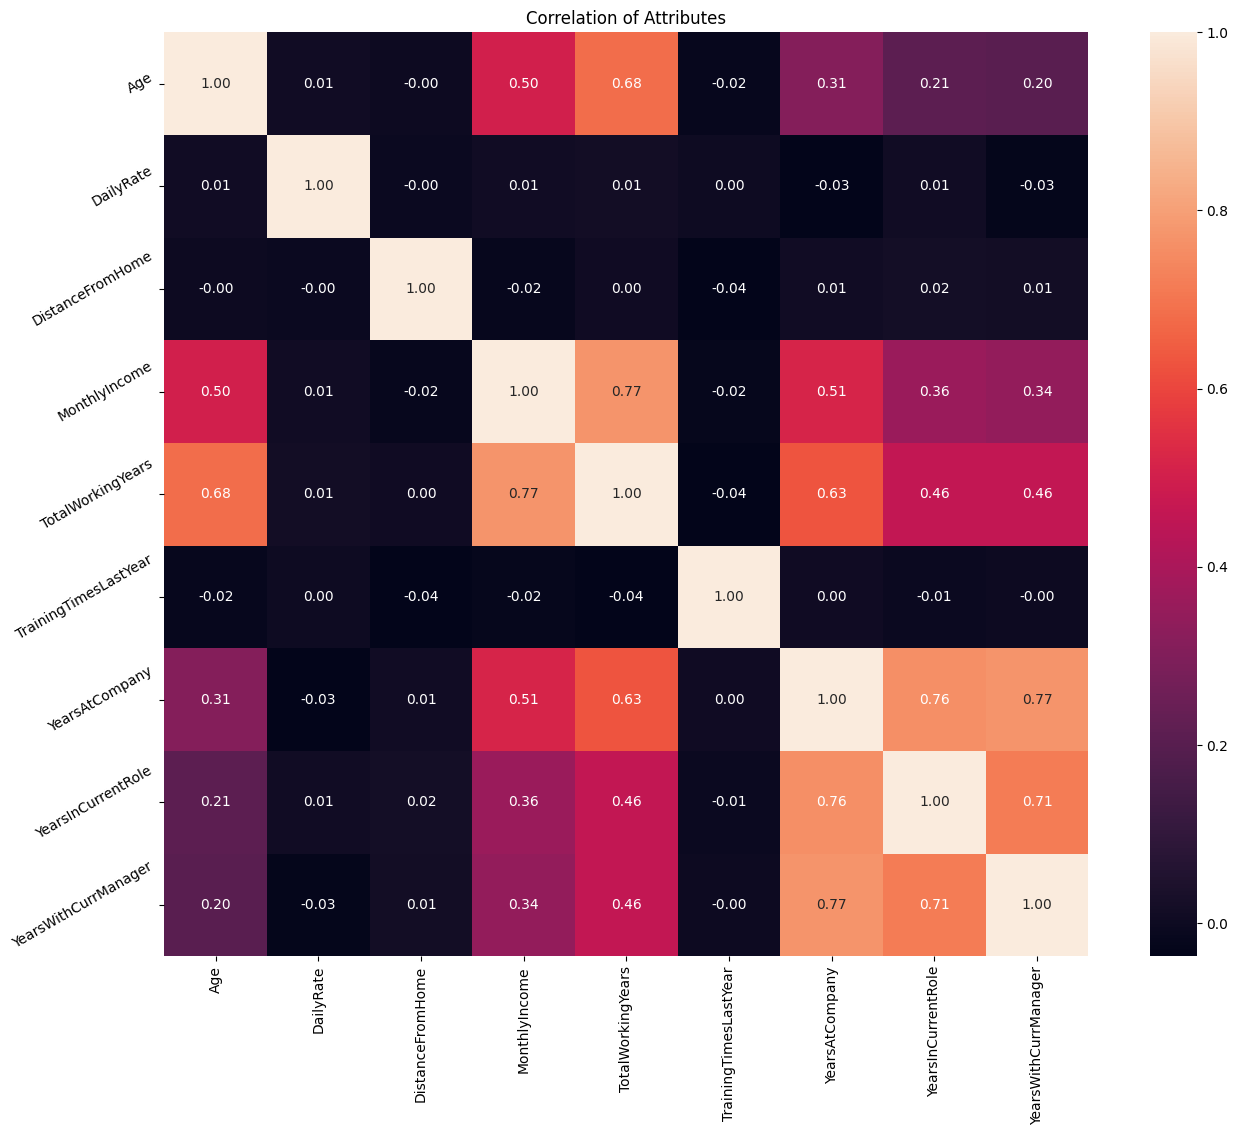

In [ ]:
plt.figure(figsize=(16,12))
plt.title('Correlation of Attributes')
a = sns.heatmap(correlation, square=True, annot=True, fmt='.2f', linecolor='Blue')
a.set_xticklabels(a.get_xticklabels(), rotation=90)
a.set_yticklabels(a.get_yticklabels(), rotation=30)
plt.show()

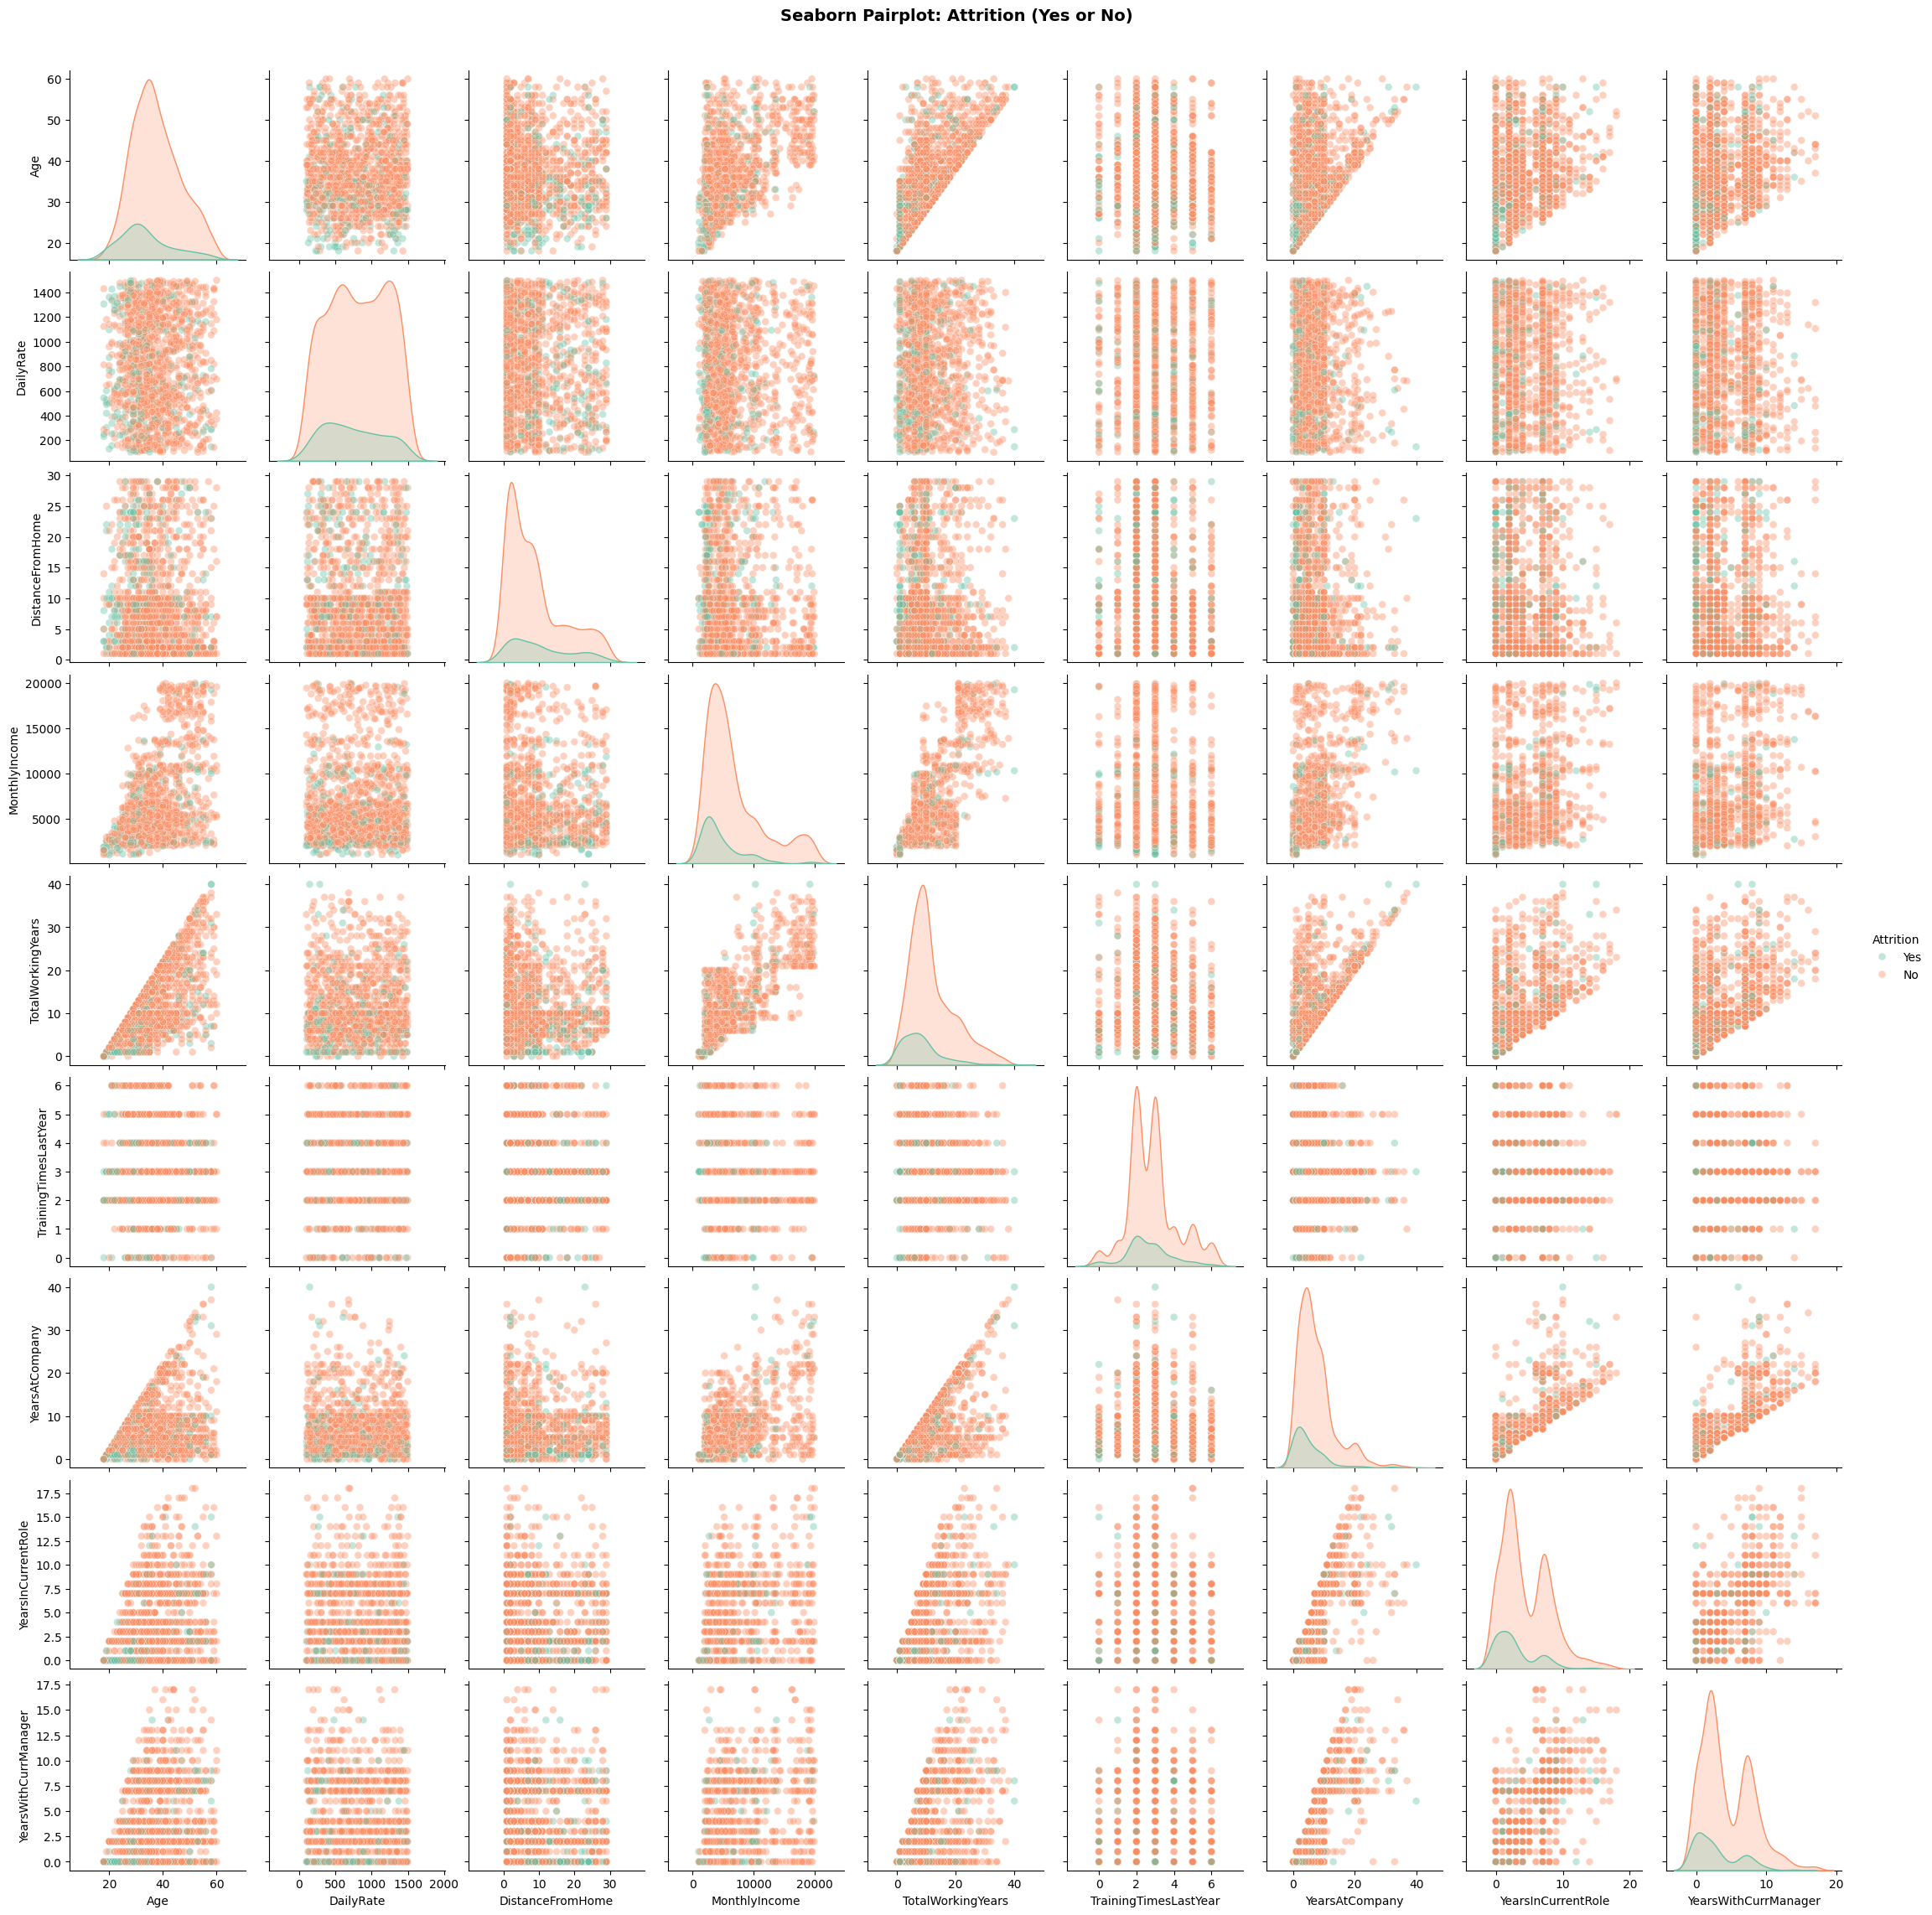

In [26]:
df_sns = df[numeric_features].copy()
df_sns["Attrition"] = df["Attrition"]

# Seaborn pairplot
sns.pairplot(
    df_sns,
    diag_kind="kde",        # KDE on diagonals instead of hist
    corner=False,           # Only lower triangle (no duplicates)
    palette="Set2",         # Nice color palette
    vars=numeric_features,     # the same set of features
    hue="Attrition",           # color by target
    plot_kws={"alpha": 0.4, "s": 40}
)

plt.suptitle("Seaborn Pairplot: Attrition (Yes or No)", y=1.02, fontsize=14, weight="bold")
plt.show()

No continuous features are highly correlated.

Columns 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours' provide no significant contribution to prediction of target.

In [ ]:
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])

Encoding Target.

In [ ]:
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1})

In [ ]:
df = pd.get_dummies(df, columns=['BusinessTravel','Department','EducationField','JobRole','MaritalStatus'], dtype=int)
df['OverTime'] = df['OverTime'].map({'No': 0, 'Yes': 1})

In [ ]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,3,2,4,5993,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,3,2,2,2,5130,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,4,2,1,3,2090,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,3,1,3,2909,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,3,1,2,3468,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,4,2,4,2571,...,1,0,0,0,0,0,0,0,1,0
1466,39,0,613,6,1,4,2,3,1,9991,...,0,0,0,0,0,0,0,0,1,0
1467,27,0,155,4,3,2,4,2,2,6142,...,0,0,1,0,0,0,0,0,1,0
1468,49,0,1023,2,3,4,2,2,2,5390,...,0,0,0,0,0,1,0,0,1,0


In [ ]:
y = df['Attrition']
X = df.drop(columns=['Attrition'])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()

# Create copies to preserve your structure cleanly
X_train_scaled = x_train.copy()
X_test_scaled = x_test.copy()

# Fit on training data, then transform both training and testing datasets
X_train_scaled[numeric_features] = scaler.fit_transform(x_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(x_test[numeric_features])

print("Data Preparation Complete!")
print(f"Training matrices shape: {X_train_scaled.shape}")
print(f"Testing matrices shape: {X_test_scaled.shape}")

Data Preparation Complete!
Training matrices shape: (1176, 43)
Testing matrices shape: (294, 43)


In [ ]:
import os

# Define the directory path
output_dir = '/content/drive/MyDrive/COMM075/data'

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Combine X_train and y_train into a single training DataFrame
df_train = pd.concat([X_train_scaled, y_train], axis=1)
df_train.to_csv(os.path.join(output_dir, 'train_data_ibm.csv'), index=False)
print('Training data saved to train_data_ibm.csv')

Training data saved to train_data_ibm.csv


In [ ]:
import os

# Define the directory path
output_dir = '/content/drive/MyDrive/COMM075/data'

# Create the directory if it doesn't exist (ensure it exists before saving test data)
os.makedirs(output_dir, exist_ok=True)

# Combine X_test and y_test into a single testing DataFrame
df_test = pd.concat([X_test_scaled, y_test], axis=1)
df_test.to_csv(os.path.join(output_dir, 'test_data_ibm.csv'), index=False)
print('Testing data saved to test_data_ibm.csv')

Testing data saved to test_data_ibm.csv


In [ ]:
df_train = pd.read_csv(os.path.join(output_dir, "train_data_ibm.csv"))
df_test = pd.read_csv(os.path.join(output_dir, "test_data_ibm.csv"))

In [ ]:
df_train

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Attrition
0,1.090194,1.049455,-0.899915,4,2,4,4,2,2.026752,0,...,1,0,0,0,0,0,1,0,0,0
1,-1.634828,-0.523449,-0.899915,1,3,3,1,4,-0.864408,0,...,0,0,0,0,0,0,0,1,0,0
2,0.981193,-0.992080,-0.777610,1,1,3,4,3,2.347706,0,...,1,0,0,0,0,0,0,1,0,0
3,-1.307825,-0.453653,0.445433,1,2,3,1,3,-0.956202,0,...,0,0,0,0,0,1,0,1,0,0
4,0.654191,0.491086,-0.043784,5,4,3,2,3,-0.185956,1,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,-1.525827,-0.939733,-0.288393,3,3,3,1,4,-0.917721,1,...,0,0,0,0,0,1,1,0,0,1
1172,0.109186,0.511028,-0.899915,2,2,3,2,1,0.075020,0,...,0,0,0,0,1,0,1,0,0,0
1173,-1.634828,-1.463203,-0.166088,1,2,1,1,1,-0.879886,0,...,0,0,0,0,0,0,0,1,0,0
1174,-0.108815,-0.932255,-0.899915,4,4,3,2,2,0.089853,1,...,0,0,0,1,0,0,0,1,0,0


In [ ]:
df_test

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Attrition
0,-1.416826,0.064832,0.445433,2,4,3,1,2,-0.969745,0,...,0,0,0,0,0,1,0,1,0,0
1,0.763191,0.780241,-0.899915,1,1,4,1,4,-0.974474,0,...,0,0,0,1,0,0,0,1,0,0
2,-0.653820,-0.289134,-0.288393,3,3,2,3,4,1.077650,0,...,1,0,0,0,0,0,1,0,0,0
3,0.763191,0.984644,-0.655306,2,3,4,5,1,2.718533,0,...,1,0,0,0,0,0,1,0,0,0
4,-0.108815,-1.211439,-0.043784,3,4,2,1,3,-0.678457,1,...,0,0,0,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,0.654191,-1.395900,-0.899915,3,2,3,1,4,-0.645997,0,...,0,0,0,0,0,0,0,0,1,0
290,0.763191,-1.580361,-1.022219,4,2,4,2,1,-0.324828,0,...,0,0,0,0,0,0,0,1,0,0
291,-0.108815,1.625272,0.445433,5,2,2,2,1,-0.088144,1,...,0,0,0,0,1,0,1,0,0,1
292,2.071202,1.124236,-1.022219,2,1,3,1,1,-0.962651,0,...,0,0,0,1,0,0,0,1,0,0
